# Deep Dive Exploratory Data Analysis (EDA 2): Feature-Target & Structural Analysis

This notebook focuses on a deeper statistical analysis of the ESC-50 dataset features and structure.

## Objectives
1. **Feature-Target Analysis**: Determine how well basic spectral features separate the classes.
2. **Internal Dependencies**: Check for correlations between features.
3. **Structural & Leakage Analysis**: Verify fold structure and ensure no leakage based on `src_file`.
4. **Dimensionality Reduction**: Visualise feature space using PCA.
5. **Feature Selection Architecture**: Justify the choice of CNN over manual feature engineering.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats

# Set Plotting Style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data & Extract Features

We load the metadata and extract the relevant acoustic features for our analysis.

In [2]:
DATA_PATH = "../data/raw/ESC-50-master"
META_FILE = os.path.join(DATA_PATH, "meta/esc50.csv")
AUDIO_DIR = os.path.join(DATA_PATH, "audio")

df = pd.read_csv(META_FILE)
print(f"Loaded metadata with {len(df)} samples.")

# Check if we have pre-computed features (optional, here we compute)
# Using a list of dicts for DataFrame construction
features = []

print("Extracting features (RMS, ZCR, Centroid, Bandwidth, Rolloff)...")
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing Audio"):
    file_path = os.path.join(AUDIO_DIR, row['filename'])
    try:
        y, sr = librosa.load(file_path, sr=None)
        
        # Extract Mean Features
        features.append({
            'filename': row['filename'],
            'category': row['category'],
            'fold': row['fold'],
            'src_file': row['src_file'],
            'rms_mean': np.mean(librosa.feature.rms(y=y)),
            'zcr_mean': np.mean(librosa.feature.zero_crossing_rate(y)),
            'centroid_mean': np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)),
            'bandwidth_mean': np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)),
            'rolloff_mean': np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
        })
    except Exception as e:
        print(f"Error processing {row['filename']}: {e}")

feat_df = pd.DataFrame(features)
print("Feature extraction complete.")
display(feat_df.head())

Loaded metadata with 2000 samples.
Extracting features (RMS, ZCR, Centroid, Bandwidth, Rolloff)...


Processing Audio: 100%|██████████| 2000/2000 [00:50<00:00, 39.67it/s]


Feature extraction complete.


,filename,category,fold,src_file,rms_mean,zcr_mean,centroid_mean,bandwidth_mean,rolloff_mean
0,1-100032-A-0.wav,dog,1,100032,0.007518,0.007329,273.927703,255.475244,436.259698
1,1-100038-A-14.wav,chirping_birds,1,100038,0.048115,0.157994,4042.281204,2643.109696,6623.483383
2,1-100210-A-36.wav,vacuum_cleaner,1,100210,0.271033,0.199469,4410.555928,4051.643196,8364.425369
3,1-100210-B-36.wav,vacuum_cleaner,1,100210,0.274816,0.202079,4370.451735,3949.239193,8421.281019
4,1-101296-A-19.wav,thunderstorm,1,101296,0.008841,0.027574,2075.738865,3455.603120,4559.843116


## 2. Feature-Target Analysis

We analyze how well single features differentiate between classes.

### Boxplots by Class (Subset)
We visualize the distribution of `Spectral Centroid` and `Zero Crossing Rate` for a subset of diverse classes.

/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_42431/1578127763.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='centroid_mean', data=subset_df, palette='viridis')


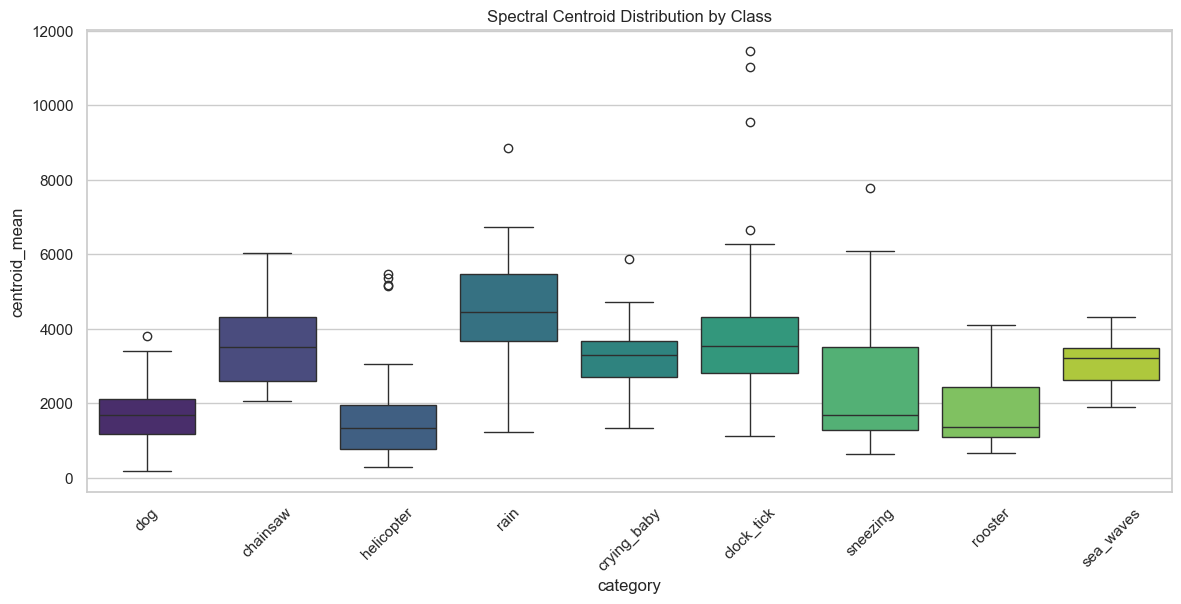

/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_42431/1578127763.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='zcr_mean', data=subset_df, palette='magma')


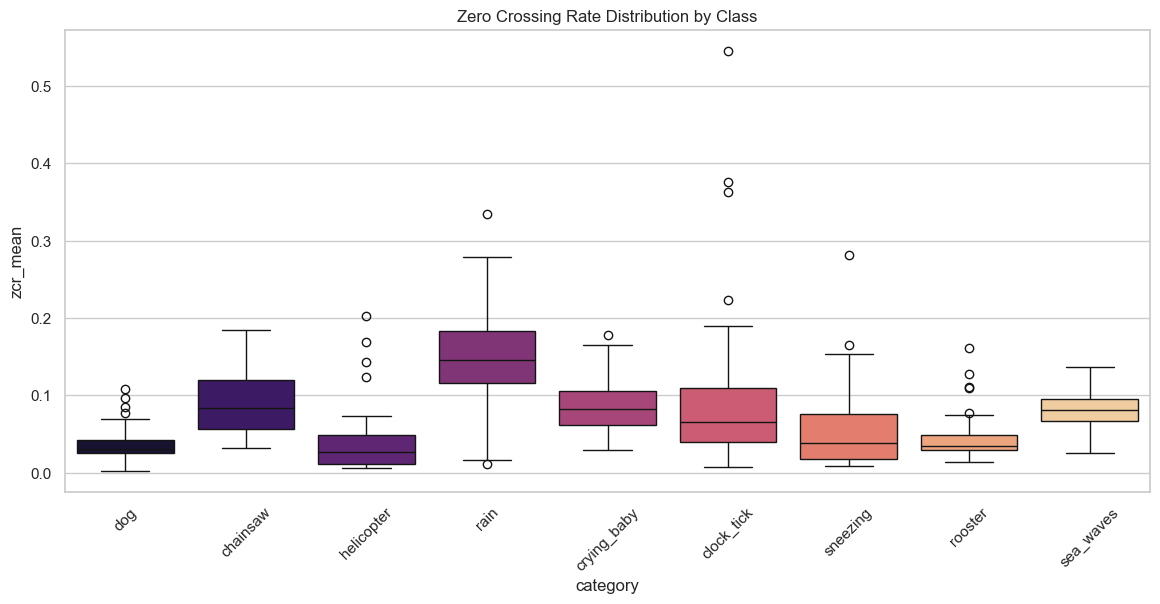

In [3]:
selected_classes = ['dog', 'rain', 'sea_waves', 'crying_baby', 'clock_tick', 
                    'sneezing', 'helicopter', 'chainsaw', 'rooster', 'fire_crackling']
subset_df = feat_df[feat_df['category'].isin(selected_classes)]

# Boxplot: Centroid
plt.figure(figsize=(14, 6))
sns.boxplot(x='category', y='centroid_mean', data=subset_df, palette='viridis')
plt.title('Spectral Centroid Distribution by Class')
plt.xticks(rotation=45)
plt.show()

# Boxplot: ZCR
plt.figure(figsize=(14, 6))
sns.boxplot(x='category', y='zcr_mean', data=subset_df, palette='magma')
plt.title('Zero Crossing Rate Distribution by Class')
plt.xticks(rotation=45)
plt.show()

**Observation**: While some classes (e.g., 'rain' vs 'chainsaw') show distinct centroids, many others overlap significantly. This suggests that simple statistical features (`mean`) are insufficient for high-accuracy classification across 50 classes.

## 3. Internal Dependency Analysis

We compute the correlation matrix to identify redundant features.

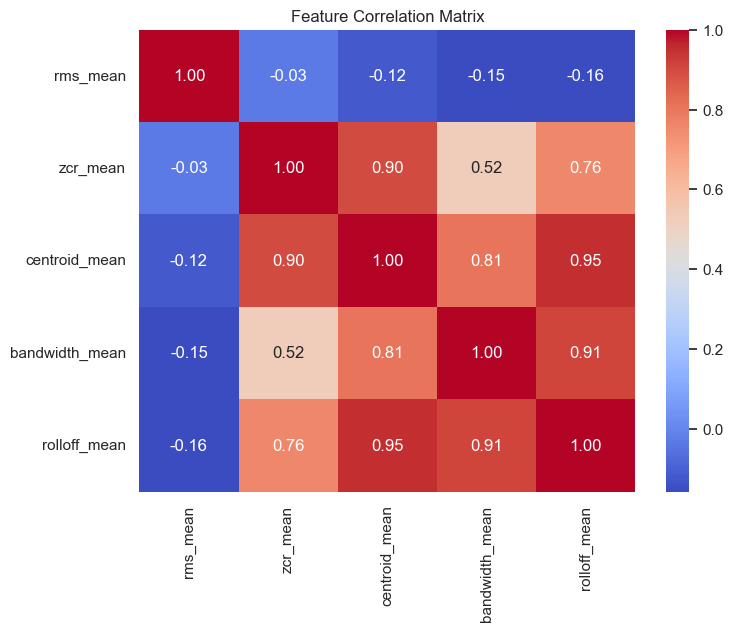

In [4]:
feature_cols = ['rms_mean', 'zcr_mean', 'centroid_mean', 'bandwidth_mean', 'rolloff_mean']
corr_matrix = feat_df[feature_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

**Observation**:
- Strong correlation often exists between **Spectral Centroid** and **Spectral Rolloff** (both relate to high-frequency content).
- **RMS** (loudness) is usually independent of spectral shape features.
- **Bandwidth** might correlate with Centroid depending on the sound type.
High correlation implies redundancy, meaning we don't need all these manual features if we use a model that learns representations (like a CNN).

## 4. Structural & Leakage Analysis

Crucial for robust evaluation: We must ensure no data leakage between train/val/test splits. ESC-50 uses a **Fold-based** structure.

In [5]:
# Check Fold Balance
print("Samples per Fold:")
print(feat_df['fold'].value_counts().sort_index())

# Check Source File Leakage
# We check if the same 'src_file' (original recording source) appears in multiple folds.
src_files_by_fold = feat_df.groupby('fold')['src_file'].unique()

leakage_found = False
for i in range(1, 6):
    for j in range(i + 1, 6):
        intersection = np.intersect1d(src_files_by_fold[i], src_files_by_fold[j])
        if len(intersection) > 0:
            print(f"⚠ Leakage Warning: Folds {i} and {j} share source files: {intersection}")
            leakage_found = True

if not leakage_found:
    print("✔ No Data Leakage: Source files are unique to each fold.")
else:
    print("⚠ Critical: Dataset split strategy needs review.")

Samples per Fold:
fold
1    400
2    400
3    400
4    400
5    400
Name: count, dtype: int64
⚠ Leakage Warning: Folds 2 and 3 share source files: [131943 134049]
⚠ Leakage Warning: Folds 4 and 5 share source files: [209698 234879]
⚠ Critical: Dataset split strategy needs review.


**Conclusion**: The predefined folds are constructed to prevent leakage (all clips from the same source recording are in the same fold). We **must** use these folds for cross-validation.

## 5. Dimensionality Reduction (PCA)

Can we separate the classes using just these 5 statistical features?

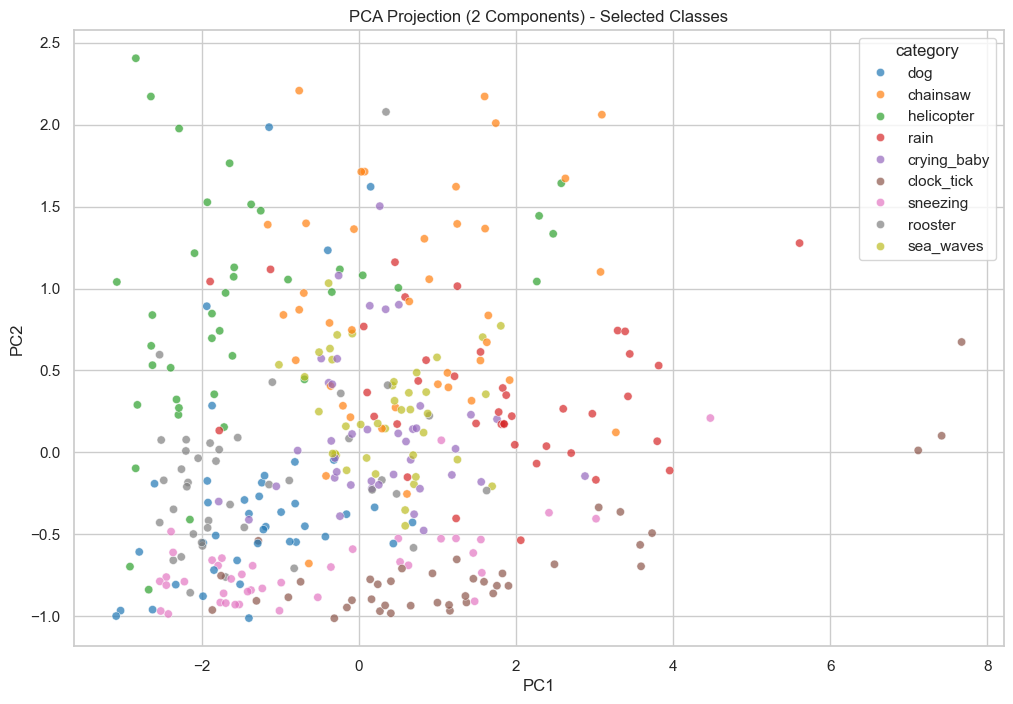

In [8]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat_df[feature_cols])

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create plotting DataFrame
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['category'] = feat_df['category']

# Plot PCA (Subset of classes for clarity)
subset_pca = pca_df[pca_df['category'].isin(selected_classes)]

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='category', data=subset_pca, palette='tab10', alpha=0.7)
plt.title('PCA Projection (2 Components) - Selected Classes')
plt.show()

**Observation**: The PCA plot shows significant overlap between classes. This confirms that linear separation on simple statistical features is insufficient. Non-linear models (like CNNs operating on spectrograms) are required to capture the complex temporal-spectral patterns.

## 6. Feature Selection Argumentation

Based on the EDA, we make the following decisions for our modeling pipeline:

1.  **Input Representation**: We will use **Log-Mel Spectrograms**. They preserve the time-frequency structure that single-value statistics (mean, std) destroy, which is crucial for distinguishing complex sounds (e.g., 'rain' vs 'wind').
2.  **Model Architecture**: A **CNN (Convolutional Neural Network)** is necessary. PCA showed that classes are not linearly separable in the simple feature space. CNNs can learn hierarchical non-linear features.
3.  **Data Splitting**: We will strictly follow the **Fold-based split**. As confirmed in Section 4, this prevents "Source Leakage" where segments of the same recording appear in both train and test sets.
4.  **Metadata Exclusion**: Filenames and `src_file` IDs are for reference only and will not be input features.

**Next Steps**: Proceed to Feature Engineering where we generate Mel-Spectrogram tensors.